## Задание

1. Скачайте текст произведения «Война и мир»: ссылка на GitHub.
2. Очистите его, оставив только русские буквы и символы пробела.
3. Постройте матрицу переходных вероятностей.
4. Посчитайте вероятность встретить строку из четырёх символов, которая начинается на букву «П» и заканчивается на букву «Р».
5. Используя матрицу переходных вероятностей, сгенерируйте слово, начинающееся с буквы «Б» длиной восемь символов.
6. Выберите ряд из предыдущих домашних заданий по временным рядам и оцените его через HMM.
7. Попробуйте построить через среднее каждой компоненты наивный прогноз ряда.

In [256]:
pip install hmmlearn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib inline
sns.set()

In [3]:
with open('output.txt', 'w') as outfile:
    for f in ['/Users/sofagusina/Desktop/код/machine_learning/machine_learning/ML/Временные ряды/Случайные марковские  процессы/Том /tom_1.txt', '/Users/sofagusina/Desktop/код/machine_learning/machine_learning/ML/Временные ряды/Случайные марковские  процессы/Том /tom_2.txt','/Users/sofagusina/Desktop/код/machine_learning/machine_learning/ML/Временные ряды/Случайные марковские  процессы/Том /tom_3.txt','/Users/sofagusina/Desktop/код/machine_learning/machine_learning/ML/Временные ряды/Случайные марковские  процессы/Том /tom_4.txt']:
        with open(f, 'r') as infile:
            outfile.write(infile.read())

## Очистка текста и подготовка данных к построению матрицы вероятностей

In [4]:
with open ('output.txt','r') as f:
    text = f.read().lower()

text = re.sub('[^а-я]','',text)



In [5]:
rus = 'абвгдеёжзийклмнопрстуфхцчшщъыьэюя'
dict_rus = {l:i for i,l in enumerate(rus)}


In [6]:
matrix = np.zeros((len(rus),len(rus)))
len(matrix)

33

In [93]:
# text_1 = 'абрикос'
# for a,b in zip(text_1[:-1],text_1[1:]):
#     print(a,b)
# text_1[:-1]
# ['g','h','r','e']
# ['h','r','e','l']

In [7]:
for cp,cn in zip(text[:-1],text[1:]): ## 
    """
    объединяет по такому признаку
    text_1 = 'ghrel' 
    text[:-1] = ['g','h','r','e'], 
    text[1:] = ['h','r','e','l']
    gh,hr,re,el - создает пары
    """
    matrix[dict_rus[cp],dict_rus[cn]] += 1 ## на пересения номеров букв пар в алфавите будет ставиться количество встреч этих пар (пара аб будет занесена в строку 1 столбец 2)


In [8]:
matrix = (matrix/matrix.sum(axis=1)[:,None])

/var/folders/07/xx2bf7ss4g30z8mzlm1lcbqr0000gn/T/ipykernel_89684/422671818.py:1: RuntimeWarning: invalid value encountered in divide
  matrix = (matrix/matrix.sum(axis=1)[:,None])


In [9]:
df = pd.DataFrame(matrix,index = (c for c in rus),columns= (c for c in rus))


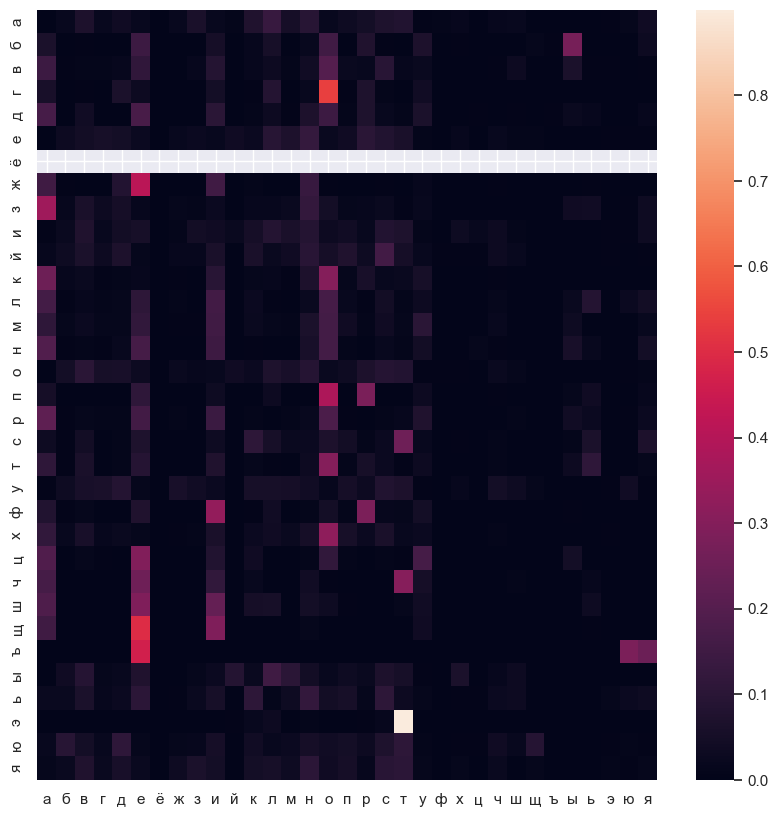

In [10]:
plt.figure(figsize=(10,10))
sns.heatmap(df)
plt.show()

Чаще всего в тексте встречаются следующие пвры букв: е и щ, е и ъ, е и ж, о и г. Вообще не встречается буква ё

## Вероятность встретить строку из четырёх символов, которая начинается на букву «П» и заканчивается на букву «Р».

In [12]:
start = dict_rus['п']
end = dict_rus['р']
prior = 1/len(rus)

for c in rus:
    for i in rus:
        proba = prior * matrix[start,dict_rus[c]]*matrix[dict_rus[c],dict_rus[i]]*matrix[dict_rus[c],end] ## считаем вероятность вхождения слова через произведение вероятностей внутри матрицы
        if proba > 0:
            word = ''.join(['п',c,i,'р'])
            print(word,proba)

паар 2.5207649190691473e-07
пабр 1.3769083850387136e-06
павр 5.033602904430531e-06
пагр 1.3586764375108549e-06
падр 2.836256880638179e-06
паер 1.5651730605981232e-06
пажр 1.3844389720610899e-06
пазр 4.627347551907594e-06
паир 1.456970415487136e-06
пайр 6.82112645553145e-07
пакр 5.640013333074522e-06
палр 9.745372300325818e-06
памр 3.6832497473128278e-06
панр 6.84134013648625e-06
паор 1.3491641170615373e-06
папр 2.598052522719852e-06
парр 3.540168593887677e-06
паср 5.479096578806901e-06
патр 5.957090681385108e-06
паур 5.132689575777588e-07
пафр 6.54368377575969e-07
пахр 1.1315697867833985e-06
пацр 1.2048939235802212e-07
пачр 1.2655349664446205e-06
пашр 1.4486471350939832e-06
пащр 2.584180388731264e-07
паэр 3.1430292151286697e-07
паюр 8.172668652705317e-07
паяр 2.7379629026618976e-06
пбар 5.01354314443704e-09
пббр 6.854825415865303e-11
пбвр 4.6460483374198175e-10
пбгр 5.902766330328457e-11
пбдр 1.2948003563301131e-10
пбер 1.0838240629751475e-08
пбжр 4.189059976362131e-11
пбзр 1.904118171

## Генерация слова, начинающегося буквы «Б», длиной восемь символов.

In [13]:
s = []
start = 'б'
s.append(start)
lenght_word = 8

for i in range(lenght_word):
    index = dict_rus[s[i]] ## достаем индекс каждого элемента строки из словаря
    next_ = np.random.choice(list(rus),p=matrix[index]) ## генерируем следующий символ исходя из вероятности распределения   𝑃(𝑋𝑛+1|𝑋𝑛)
    s.append(next_)
    word = ''.join(s)

print(word)



бумбядогл


## Оценка ряда через HMM

In [19]:
weekly_closing_df = pd.read_csv('/Users/sofagusina/Desktop/код/machine_learning/machine_learning/ML/Временные ряды/Случайные марковские  процессы/Материалы к занятию «Знакомство с временными рядами»/Series/weekly-closings-of-the-dowjones-.csv')
type(weekly_closing_df)

pandas.core.frame.DataFrame

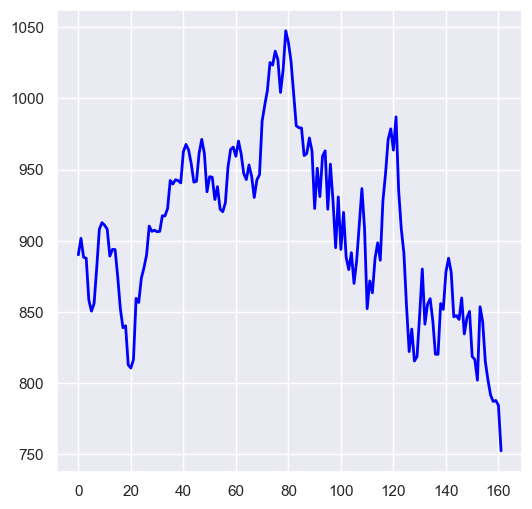

In [24]:

plt.figure(figsize=(6,6))
plt.plot(weekly_closing_df['Close'], color='blue', linewidth='2', label='Real')
plt.show()

In [25]:
from hmmlearn.hmm import GaussianHMM

In [26]:
values_series = weekly_closing_df['Close'].values.reshape(-1,1)



In [28]:
for n in range(1,14):
    model_HMM = GaussianHMM(n_components=n,covariance_type='diag',n_iter=1000)
    model_HMM.fit(values_series)
    print(n, model_HMM.score(values_series))

1 -894.2620483582106
2 -820.6339121612166
3 -786.833736595412
4 -785.9827356949978
5 -772.0365898152255
6 -750.8202808328614


Fitting a model with 167 free scalar parameters with only 162 data points will result in a degenerate solution.
Fitting a model with 194 free scalar parameters with only 162 data points will result in a degenerate solution.


7 -761.7513420286349
8 -756.451198540598
9 -709.5942459969975
10 -756.5015573043721
11 -722.7603290965999
12 -734.6621867312141
13 -701.3204940573582


Модель может переобучаться при большом количестве компонет, поэтому выберем число компонент = 9, при нем модель впервые достигла низкого значения ошибки


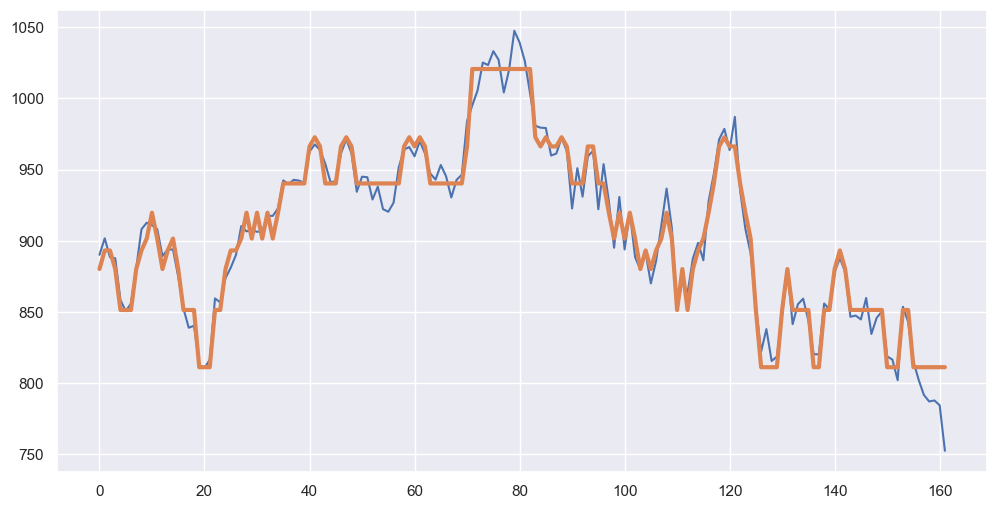

In [37]:
model_HMM = GaussianHMM(n_components=10,
                        covariance_type="diag",
                        n_iter=1000)
model_HMM.fit(values_series)

labels = model_HMM.predict(values_series)

means = np.zeros_like(values_series)
for i in range(model_HMM.n_components):
    means[labels == i] = model_HMM.means_[i] ## берем среднее значение для каждого предсказания модели
    
plt.figure(figsize=(12, 6))
plt.plot(values_series)
plt.plot(means, linewidth=3)
plt.show()

Модель показала хорошее предсказание для существующего ряда, но так как у данного ряда нет перехода состояний, то данная модель с переключениями не подходит для анализа данного ряда.